# Segmentasi Pasar Aplikasi Finance
## Analisis Review Kompetitor: US vs Indonesia

**Tujuan:** Validasi dua segmen utama berdasarkan Value Proposition Design (VPD) untuk Surfing Whale Finance:
- **Segmen A — Si Pencari Efisiensi:** Butuh konektivitas, otomatisasi, dan panduan flow akuntansi
- **Segmen B — Si Pengendali Ketat:** Butuh presisi, privasi, dan kemudahan adopsi dari kebiasaan manual

**Dataset:**
- `riset_kompetitor_US.csv` — 450 review: YNAB, Wallet (BudgetBakers), Spendee
- `riset_pasar_indo_1000.csv` — 600 review: Jenius/Moneytory, Wallet, Money Lover, Bluecoins, Monefy, Spendee

---
## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'sans-serif'
})

BLUE  = '#3A86FF'
RED   = '#FF5A5F'
GREEN = '#06D6A0'
AMBER = '#FFB703'
GRAY  = '#8D99AE'

print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load & Merge Data

In [2]:
PATH_US = '../CSV/riset_kompetitor_US.csv'
PATH_ID = '../CSV/riset_pasar_indo_1000.csv'

df_us = pd.read_csv(PATH_US)
df_id = pd.read_csv(PATH_ID)

df_us['Market'] = 'US'
df_id['Market'] = 'ID'

df_us = df_us[['App', 'Review', 'Rating', 'Sentiment_Score', 'Market']]
df_id = df_id[['App', 'Review', 'Rating', 'Sentiment_Score', 'Market']]

df = pd.concat([df_us, df_id], ignore_index=True)

df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')
df['Sentiment_Score'] = pd.to_numeric(df['Sentiment_Score'], errors='coerce')
df['Review'] = df['Review'].fillna('').str.strip()
df['Review_lower'] = df['Review'].str.lower()

app_map = {
    'Jenius_Moneytory': 'Jenius / Moneytory',
    'Wallet_BudgetBakers': 'Wallet (BudgetBakers)',
    'Money_Lover': 'Money Lover',
}
df['App_label'] = df['App'].replace(app_map)

print(f'Total reviews: {len(df)}')
print(f'US: {len(df_us)} | ID: {len(df_id)}')
df.head(3)

Total reviews: 1050
US: 450 | ID: 600


,App,Review,Rating,Sentiment_Score,Market,Review_lower,App_label
0,YNAB,It wants you to pay a monthly subscription.,1,-0.8,US,it wants you to pay a monthly subscription.,YNAB
1,YNAB,I have probably tried just about every budgeti...,5,0.6,US,i have probably tried just about every budgeti...,YNAB
2,YNAB,"App is too expensive and no free option, it is...",1,-0.8,US,"app is too expensive and no free option, it is...",YNAB


---
## 2. Market Overview

        Reviews  Avg_Rating  Avg_Sentiment  Apps
Market                                          
ID          600        3.85           0.30     6
US          450        3.54           0.12     3


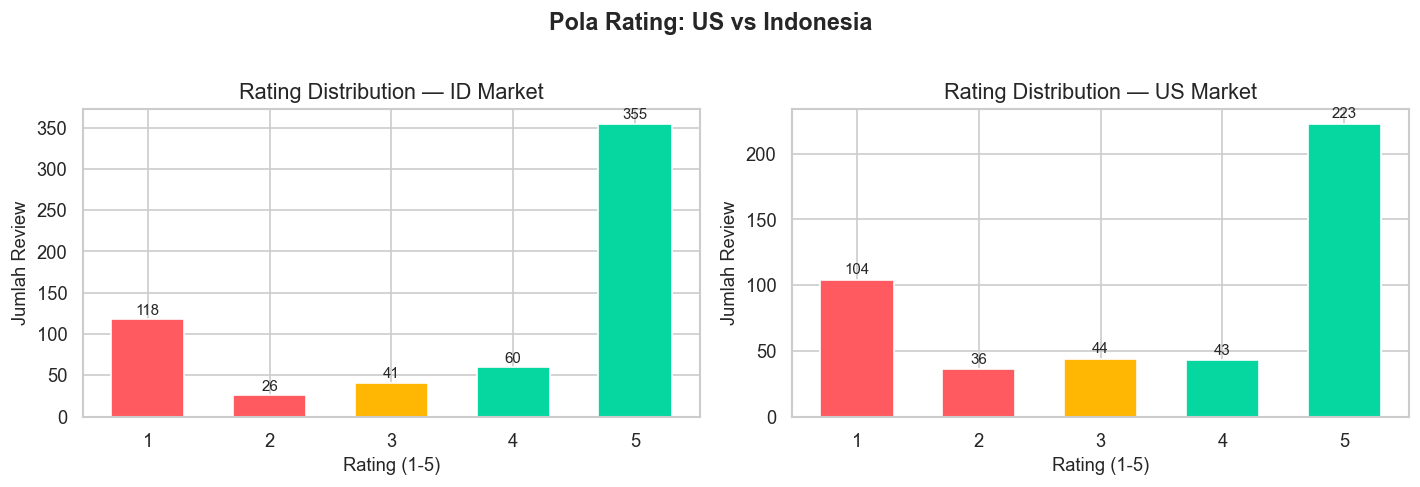


PROPORSI SENTIMEN:
  ID: Positif=69.2% | Negatif=24.0%
  US: Positif=59.1% | Negatif=31.1%


In [3]:
summary = df.groupby('Market').agg(
    Reviews=('Review', 'count'),
    Avg_Rating=('Rating', 'mean'),
    Avg_Sentiment=('Sentiment_Score', 'mean'),
    Apps=('App', 'nunique')
).round(2)
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (market, grp) in zip(axes, df.groupby('Market')):
    counts = grp['Rating'].value_counts().sort_index()
    colors = [RED if r <= 2 else AMBER if r == 3 else GREEN for r in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors, width=0.6, edgecolor='white')
    ax.set_title(f'Rating Distribution — {market} Market')
    ax.set_xlabel('Rating (1-5)')
    ax.set_ylabel('Jumlah Review')
    ax.set_xticks([1, 2, 3, 4, 5])
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

plt.suptitle('Pola Rating: US vs Indonesia', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nPROPORSI SENTIMEN:')
for market, grp in df.groupby('Market'):
    pos = (grp['Rating'] >= 4).sum() / len(grp) * 100
    neg = (grp['Rating'] <= 2).sum() / len(grp) * 100
    print(f'  {market}: Positif={pos:.1f}% | Negatif={neg:.1f}%')

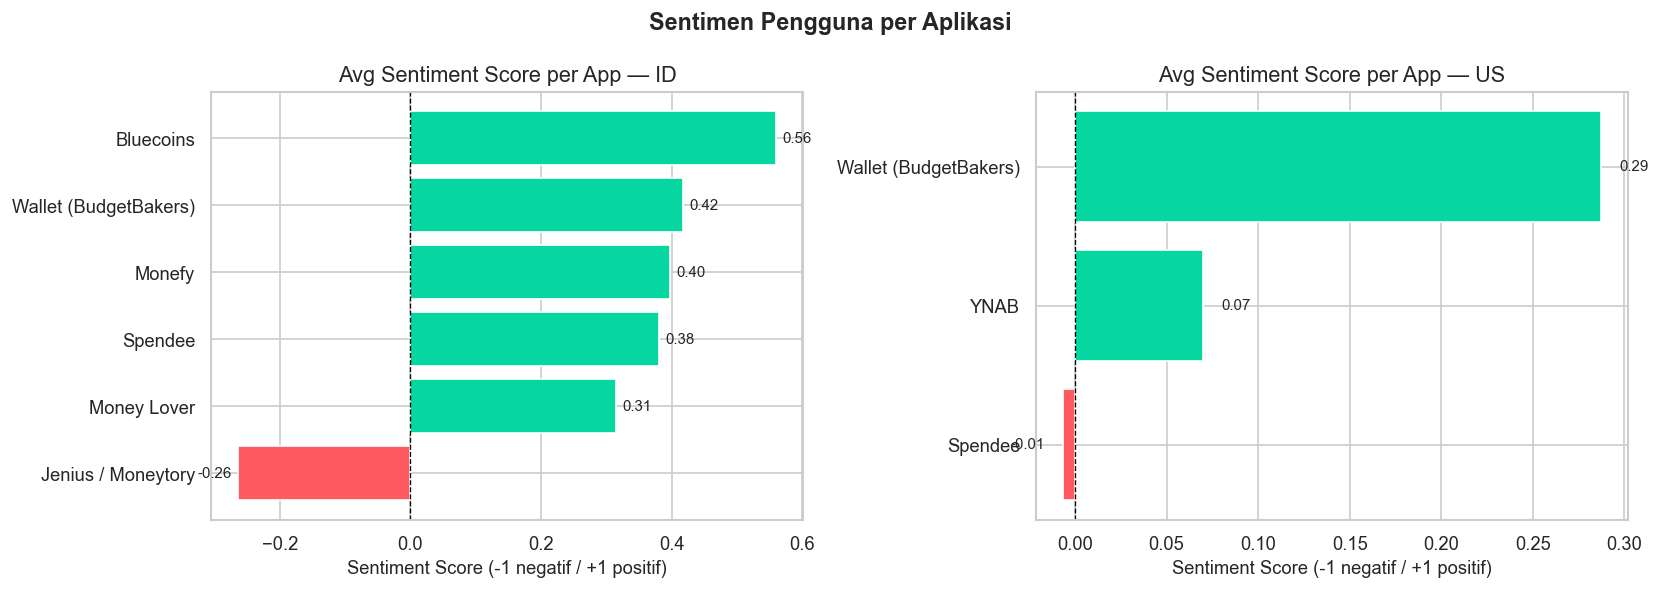

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (market, grp) in zip(axes, df.groupby('Market')):
    app_sent = grp.groupby('App_label')['Sentiment_Score'].mean().sort_values()
    colors = [GREEN if v >= 0 else RED for v in app_sent.values]
    ax.barh(app_sent.index, app_sent.values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Avg Sentiment Score per App — {market}')
    ax.set_xlabel('Sentiment Score (-1 negatif / +1 positif)')
    for i, v in enumerate(app_sent.values):
        ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}',
                va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.suptitle('Sentimen Pengguna per Aplikasi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. App Comparison

Avg Rating per App:
Market                   ID    US
App_label                        
Bluecoins              4.61   NaN
Jenius / Moneytory     2.24   NaN
Monefy                 3.91   NaN
Money Lover            3.80   NaN
Spendee                4.15  3.13
Wallet (BudgetBakers)  4.37  4.06
YNAB                    NaN  3.45


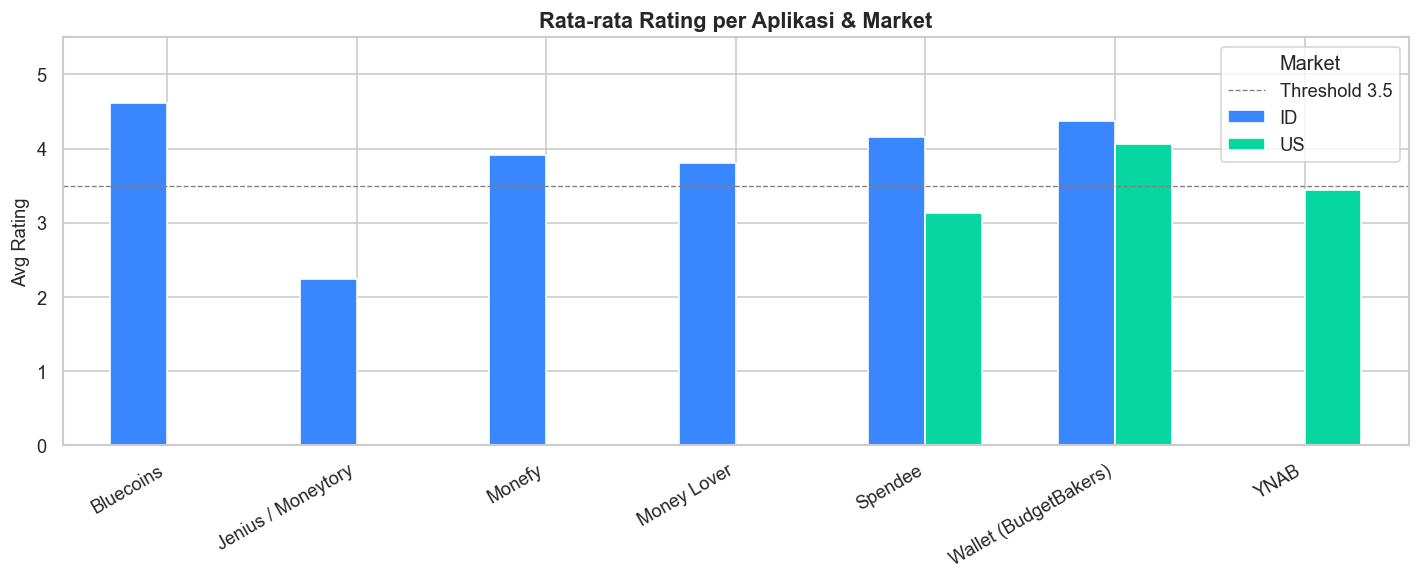

In [5]:
app_rating = df.groupby(['App_label', 'Market'])['Rating'].mean().unstack()
print('Avg Rating per App:')
print(app_rating.round(2).to_string())

fig, ax = plt.subplots(figsize=(12, 5))
app_rating.plot(kind='bar', ax=ax, color=[BLUE, GREEN], width=0.6, edgecolor='white')
ax.set_title('Rata-rata Rating per Aplikasi & Market', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Avg Rating')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.axhline(3.5, color='gray', linestyle='--', linewidth=0.8, label='Threshold 3.5')
ax.legend(title='Market')
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

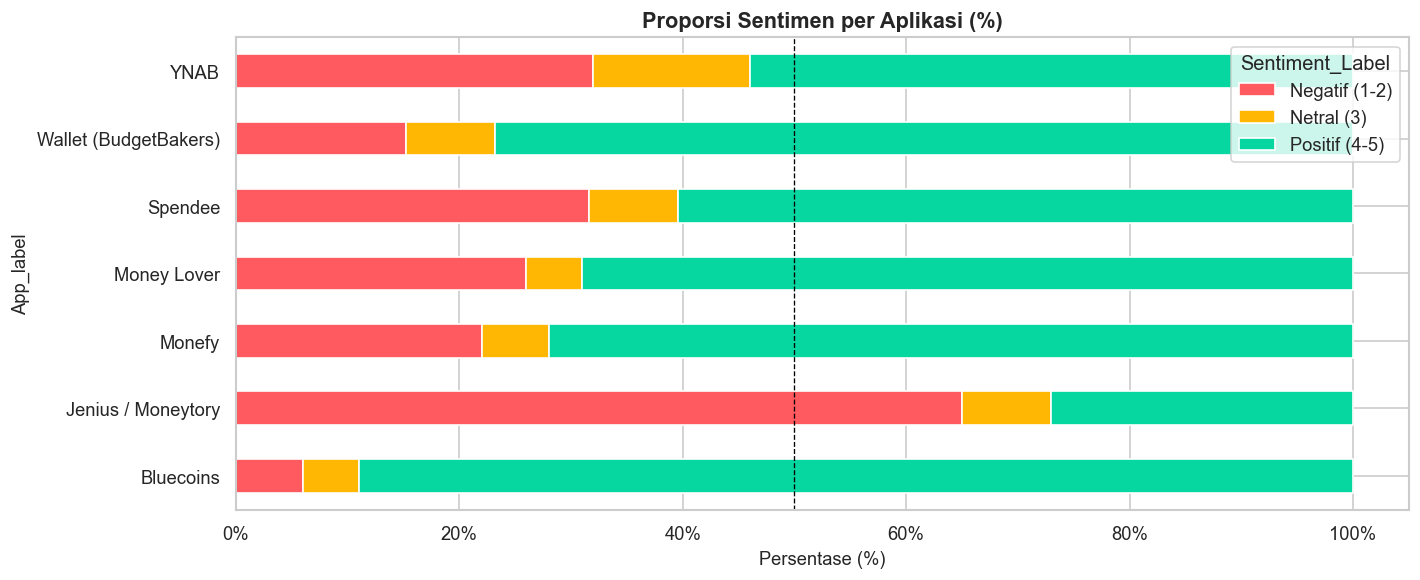


Detail % Sentimen:
Sentiment_Label        Negatif (1-2)  Netral (3)  Positif (4-5)
App_label                                                      
Bluecoins                        6.0         5.0           89.0
Jenius / Moneytory              65.0         8.0           27.0
Monefy                          22.0         6.0           72.0
Money Lover                     26.0         5.0           69.0
Spendee                         31.6         8.0           60.4
Wallet (BudgetBakers)           15.2         8.0           76.8
YNAB                            32.0        14.0           54.0


In [6]:
df['Sentiment_Label'] = df['Rating'].apply(
    lambda r: 'Positif (4-5)' if r >= 4 else ('Negatif (1-2)' if r <= 2 else 'Netral (3)')
)

pivot = df.groupby(['App_label', 'Sentiment_Label']).size().unstack(fill_value=0)
col_order = [c for c in ['Negatif (1-2)', 'Netral (3)', 'Positif (4-5)'] if c in pivot.columns]
pivot = pivot[col_order]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
pivot_pct.plot(kind='barh', stacked=True, ax=ax,
               color=[RED, AMBER, GREEN], edgecolor='white')
ax.set_title('Proporsi Sentimen per Aplikasi (%)', fontweight='bold')
ax.set_xlabel('Persentase (%)')
ax.axvline(50, color='black', linewidth=0.8, linestyle='--')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print('\nDetail % Sentimen:')
print(pivot_pct.round(1).to_string())

---
## 4. Segmentasi Berdasarkan Pain Points

Keyword mapping ke dua segmen VPD:

| Segmen | Keywords Sinyal |
|--------|----------------|
| **A — Pencari Efisiensi** | sync, bank, automatic, connect, import, template, tutorial, learn, confusing, complicated, workflow, accounting |
| **B — Pengendali Ketat** | privacy, secure, safe, simple, manual, budget, control, data, offline, easy, track |

In [7]:
SEG_A_EN = [
    'sync', 'bank', 'automatic', 'automat', 'connect', 'import', 'template',
    'tutorial', 'learn', 'confus', 'complicated', 'workflow', 'how to',
    'accounting', 'integration', 'link', 'setup', 'onboard', 'hard to use',
    'steep', 'difficult', 'understand'
]
SEG_B_EN = [
    'privacy', 'secure', 'safe', 'simple', 'manual', 'budget', 'control',
    'data', 'offline', 'easy', 'track', 'private', 'encrypt', 'no cloud'
]
SEG_A_ID = [
    'sinkron', 'otomatis', 'bank', 'hubung', 'import', 'template', 'tutorial',
    'belajar', 'ribet', 'susah', 'bingung', 'alur', 'cara', 'petunjuk',
    'terhubung', 'integrasi', 'setup', 'fitur'
]
SEG_B_ID = [
    'privasi', 'aman', 'keamanan', 'simpel', 'manual', 'budget', 'kontrol',
    'data', 'offline', 'mudah', 'catat', 'lacak', 'sederhana', 'enkripsi'
]

def score_segment(text, keywords):
    return sum(1 for kw in keywords if kw in text)

df['Score_A'] = df.apply(
    lambda r: score_segment(r['Review_lower'],
                            SEG_A_ID if r['Market'] == 'ID' else SEG_A_EN), axis=1)
df['Score_B'] = df.apply(
    lambda r: score_segment(r['Review_lower'],
                            SEG_B_ID if r['Market'] == 'ID' else SEG_B_EN), axis=1)

def assign_segment(row):
    if row['Score_A'] == 0 and row['Score_B'] == 0:
        return 'Unclassified'
    elif row['Score_A'] > row['Score_B']:
        return 'A — Pencari Efisiensi'
    elif row['Score_B'] > row['Score_A']:
        return 'B — Pengendali Ketat'
    else:
        return 'Overlap'

df['Segment'] = df.apply(assign_segment, axis=1)

seg_dist = df.groupby(['Market', 'Segment']).size().unstack(fill_value=0)
print('Distribusi Segmen per Market:')
print(seg_dist)
print('\nDalam %:')
print((seg_dist.div(seg_dist.sum(axis=1), axis=0) * 100).round(1))

Distribusi Segmen per Market:
Segment  A — Pencari Efisiensi  B — Pengendali Ketat  Overlap  Unclassified
Market                                                                     
ID                          62                    86       25           427
US                          97                   108       18           227

Dalam %:
Segment  A — Pencari Efisiensi  B — Pengendali Ketat  Overlap  Unclassified
Market                                                                     
ID                        10.3                  14.3      4.2          71.2
US                        21.6                  24.0      4.0          50.4


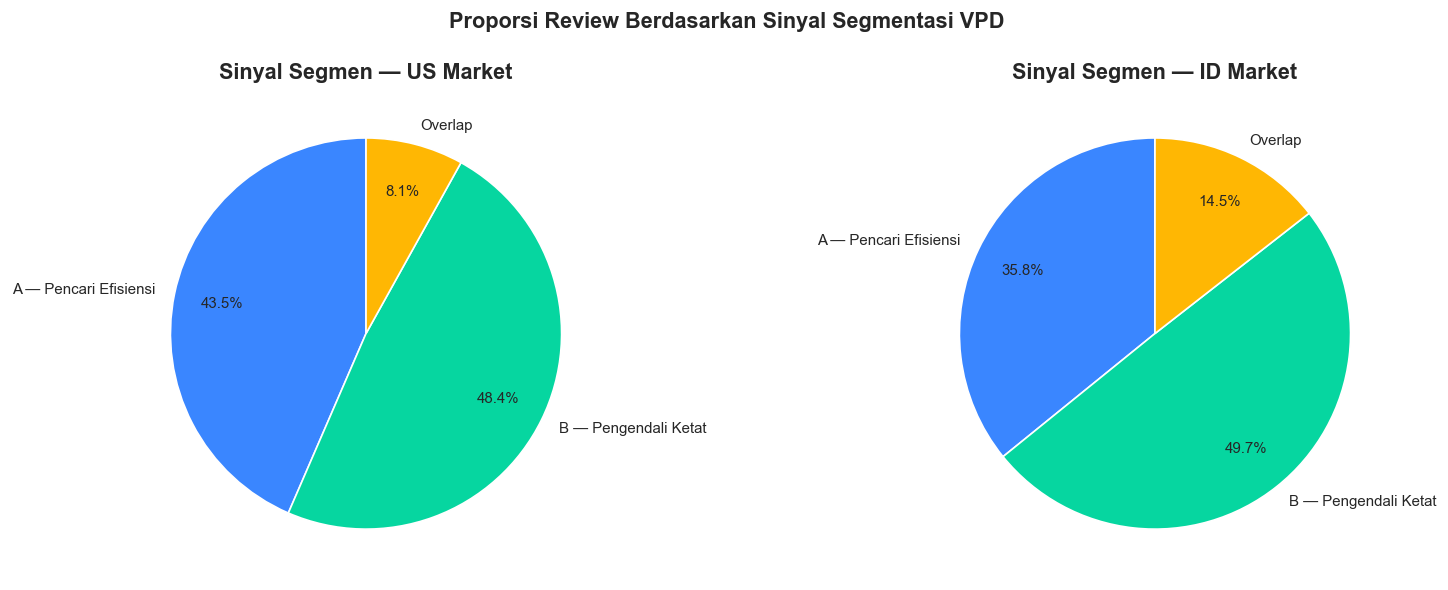

In [8]:
seg_pct = seg_dist.div(seg_dist.sum(axis=1), axis=0) * 100
colors_seg = {
    'A — Pencari Efisiensi': BLUE,
    'B — Pengendali Ketat': GREEN,
    'Overlap': AMBER,
    'Unclassified': GRAY
}

markets = [m for m in ['US', 'ID'] if m in seg_pct.index]
fig, axes = plt.subplots(1, len(markets), figsize=(13, 5))
if len(markets) == 1:
    axes = [axes]

for ax, market in zip(axes, markets):
    data = seg_pct.loc[market].drop('Unclassified', errors='ignore')
    data = data[data > 0]
    clrs = [colors_seg.get(k, GRAY) for k in data.index]
    ax.pie(data.values, labels=data.index, colors=clrs,
           autopct='%1.1f%%', startangle=90,
           textprops={'fontsize': 9}, pctdistance=0.75)
    ax.set_title(f'Sinyal Segmen — {market} Market', fontweight='bold')

plt.suptitle('Proporsi Review Berdasarkan Sinyal Segmentasi VPD', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Avg Rating per Segmen (validasi pain level berbeda):
Segment  A — Pencari Efisiensi  B — Pengendali Ketat  Overlap
Market                                                       
ID                        3.42                  4.07     3.48
US                        2.54                  4.04     3.61


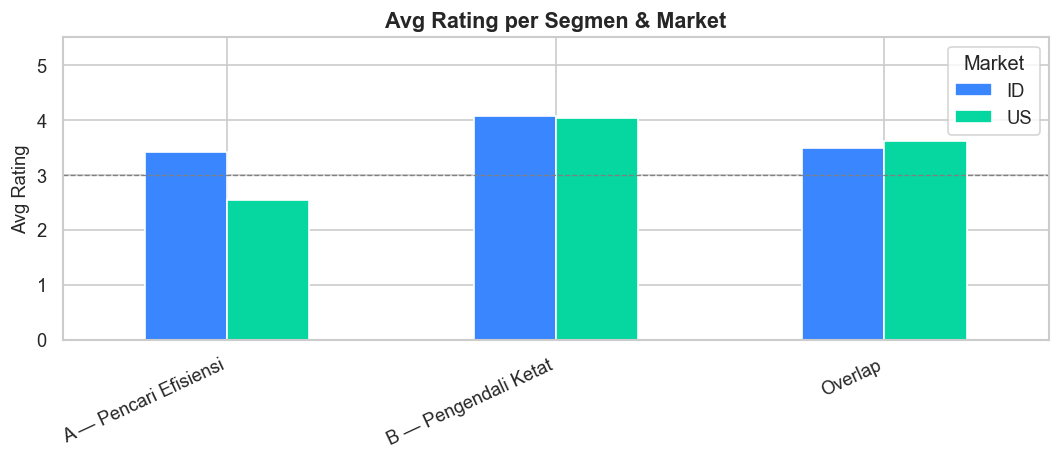

In [9]:
seg_rating = df[df['Segment'] != 'Unclassified'].groupby(['Market', 'Segment'])['Rating'].mean().unstack()
print('Avg Rating per Segmen (validasi pain level berbeda):')
print(seg_rating.round(2).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
seg_rating.T.plot(kind='bar', ax=ax, color=[BLUE, GREEN], width=0.5, edgecolor='white')
ax.set_title('Avg Rating per Segmen & Market', fontweight='bold')
ax.set_ylabel('Avg Rating')
ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.axhline(3.0, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylim(0, 5.5)
ax.legend(title='Market')
plt.tight_layout()
plt.show()

---
## 5. Keyword Frequency per Segmen

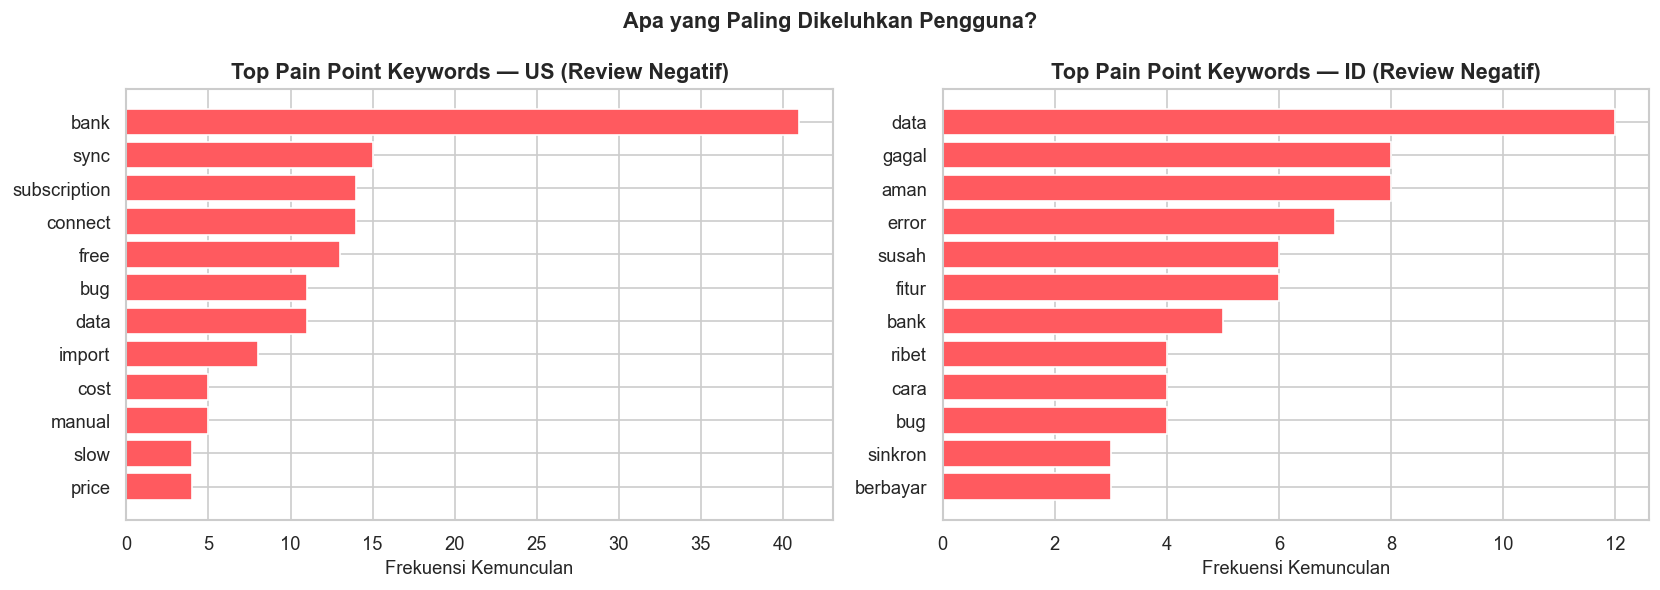

In [10]:
PAIN_KW_EN = [
    'sync', 'bank', 'connect', 'import', 'complicated', 'confusing',
    'hard to use', 'learning curve', 'tutorial', 'how to', 'setup',
    'privacy', 'secure', 'data', 'simple', 'manual', 'offline', 'expensive',
    'subscription', 'price', 'cost', 'free', 'crash', 'bug', 'slow'
]
PAIN_KW_ID = [
    'ribet', 'susah', 'bingung', 'tutorial', 'cara', 'sinkron', 'bank',
    'terhubung', 'import', 'fitur',
    'aman', 'data', 'privasi', 'sederhana', 'mudah', 'mahal', 'berbayar',
    'gratis', 'error', 'bug', 'lambat', 'gangguan', 'gagal'
]

def count_keywords(reviews_series, keywords):
    counter = Counter()
    for text in reviews_series:
        for kw in keywords:
            if kw in text:
                counter[kw] += 1
    return counter

neg_us = df[(df['Market'] == 'US') & (df['Rating'] <= 2)]['Review_lower']
neg_id = df[(df['Market'] == 'ID') & (df['Rating'] <= 2)]['Review_lower']

kw_us = count_keywords(neg_us, PAIN_KW_EN)
kw_id = count_keywords(neg_id, PAIN_KW_ID)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (market, counter) in zip(axes, [('US', kw_us), ('ID', kw_id)]):
    top = dict(counter.most_common(12))
    ax.barh(list(top.keys()), list(top.values()), color=RED, edgecolor='white')
    ax.set_title(f'Top Pain Point Keywords — {market} (Review Negatif)', fontweight='bold')
    ax.set_xlabel('Frekuensi Kemunculan')
    ax.invert_yaxis()

plt.suptitle('Apa yang Paling Dikeluhkan Pengguna?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

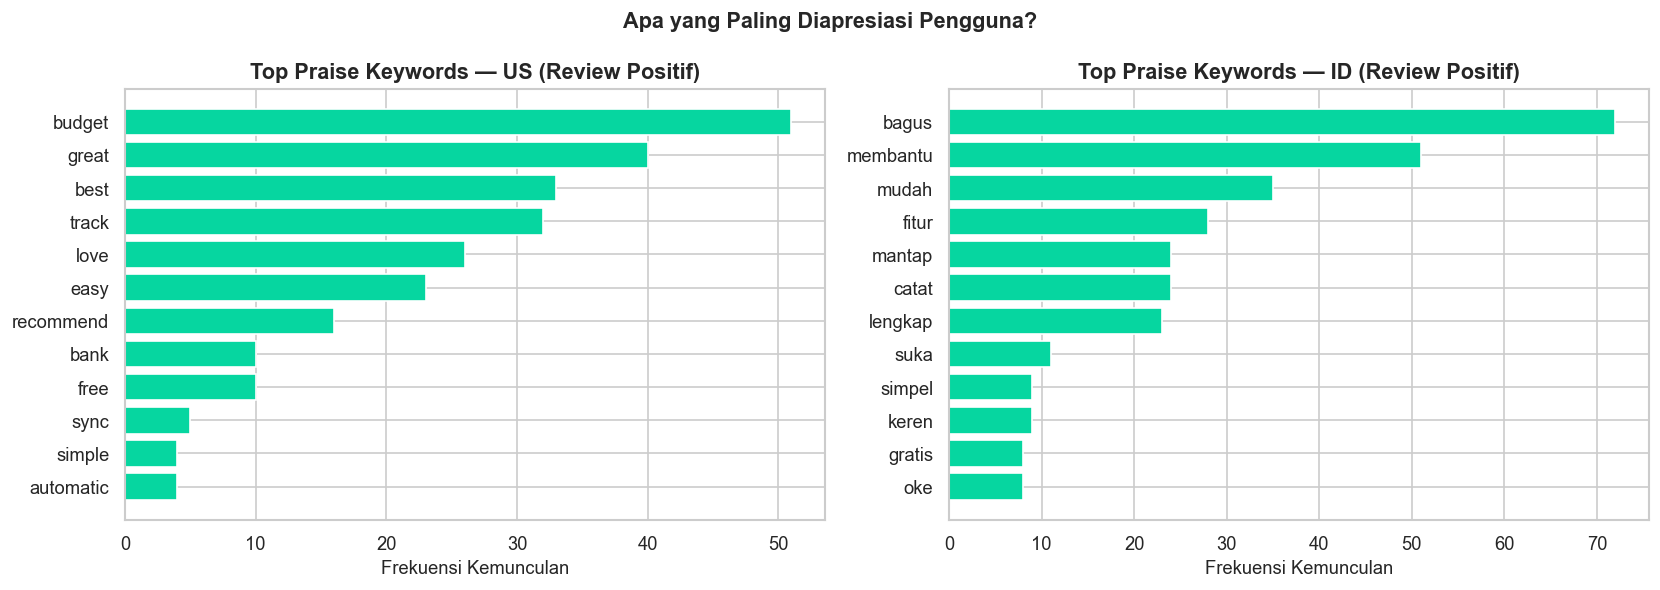

In [11]:
PRAISE_KW_EN = [
    'easy', 'simple', 'love', 'great', 'best', 'intuitive', 'sync',
    'automatic', 'bank', 'budget', 'track', 'overview', 'visual', 'chart',
    'report', 'clean', 'design', 'free', 'recommend'
]
PRAISE_KW_ID = [
    'mudah', 'bagus', 'mantap', 'keren', 'suka', 'simpel', 'membantu',
    'praktis', 'canggih', 'lengkap', 'fitur', 'gratis', 'oke', 'rekomen',
    'catat', 'laporan', 'grafik'
]

pos_us = df[(df['Market'] == 'US') & (df['Rating'] >= 4)]['Review_lower']
pos_id = df[(df['Market'] == 'ID') & (df['Rating'] >= 4)]['Review_lower']

kw_pos_us = count_keywords(pos_us, PRAISE_KW_EN)
kw_pos_id = count_keywords(pos_id, PRAISE_KW_ID)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (market, counter) in zip(axes, [('US', kw_pos_us), ('ID', kw_pos_id)]):
    top = dict(counter.most_common(12))
    ax.barh(list(top.keys()), list(top.values()), color=GREEN, edgecolor='white')
    ax.set_title(f'Top Praise Keywords — {market} (Review Positif)', fontweight='bold')
    ax.set_xlabel('Frekuensi Kemunculan')
    ax.invert_yaxis()

plt.suptitle('Apa yang Paling Diapresiasi Pengguna?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Sample Reviews per Segmen (Validasi Kualitatif)

In [12]:
def show_samples(market, segment, sentiment_label, n=5):
    subset = df[
        (df['Market'] == market) &
        (df['Segment'] == segment) &
        (df['Sentiment_Label'] == sentiment_label)
    ][['App_label', 'Review', 'Rating']].head(n)
    print(f'\n{"="*70}')
    print(f'  {market} | {segment} | {sentiment_label}')
    print(f'{"="*70}')
    for _, row in subset.iterrows():
        print(f'  [{row["App_label"]} | Rating: {row["Rating"]}]')
        print(f'  "{row["Review"][:220]}"')
        print()

show_samples('US', 'A — Pencari Efisiensi', 'Negatif (1-2)')
show_samples('ID', 'A — Pencari Efisiensi', 'Negatif (1-2)')


  US | A — Pencari Efisiensi | Negatif (1-2)
  [YNAB | Rating: 1]
  "App is too expensive and no free option, it is not intuitive to use. I have been looking for an everydollar equivalent in Canada which links to your bank account....this is not it"

  [YNAB | Rating: 2]
  "I wanted to see what the app is about and test it quickly. Installed it and it goes through a quick setup asking bunch of questions. Great. Except at the end after all the work I have done it asks me to create an account"

  [YNAB | Rating: 1]
  "keeps "forgetting" my bank account"

  [YNAB | Rating: 1]
  "Used to be incredible. But the constant UI changes have rendered it slow, clunky, and buggy. I've opened tickets only for them to be closed with no resolution. Worse yet, bank connections will just break with zero commun"

  [YNAB | Rating: 1]
  "The first and most important thing it asked me was what my monthly income was. I get paid weekly it doesn't work that way. I don't even know who this app is made for but

In [13]:
show_samples('US', 'B — Pengendali Ketat', 'Negatif (1-2)')
show_samples('ID', 'B — Pengendali Ketat', 'Negatif (1-2)')


  US | B — Pengendali Ketat | Negatif (1-2)
  [YNAB | Rating: 1]
  "$15 a month for budgeting app. No thank you."

  [YNAB | Rating: 1]
  "not great. it's a strange way to set a budget and it's overall very clunky. you assign payments that have already been made to categories and then it takes that money from what is in your accounts even though it's alread"

  [YNAB | Rating: 1]
  "a budget app that cost 14.99 a month? best budget decision you can make in uninstalling asap"

  [YNAB | Rating: 1]
  "If I could give it 0 stars I would. It's just another app that screws people over with their free trial BS. Imagine a budget app not wanting to refund a customer whose saying the app cost is outside of their budget. And "

  [YNAB | Rating: 1]
  "it's really disappointing to find out that the thing everyone recommends to help with my extremely tight budget is SO expensive! went through the motions with high hopes only to find out that NOPE! Can't afford it. And f"


  ID | B — Pengendali K

In [14]:
show_samples('US', 'B — Pengendali Ketat', 'Positif (4-5)')
show_samples('ID', 'A — Pencari Efisiensi', 'Positif (4-5)')


  US | B — Pengendali Ketat | Positif (4-5)
  [YNAB | Rating: 4]
  "I love YNAB. Please stop forcing people to watch an intro sequence when they launch the app for the first time. I already have an account and I just want to log in and get to my budget."

  [YNAB | Rating: 5]
  "Overall I highly recommend this to anyone looking to improve their budgeting! I moved to YNAB after Simple Bank closed, so it's been quite a while now. It did take some doing to get set up, but after that YNAB worked rea"

  [YNAB | Rating: 5]
  "I share this budget with everyone. I try to explain the freedom in a budget and the ability to move money from fully funded categories to over budget categories. This is the way to go!"

  [YNAB | Rating: 5]
  "I've been using YNAB for years. It is an excellent budgeting program that helps you keep track of your spending and makes it easier to save money."

  [YNAB | Rating: 5]
  "Great budgeting tool. (period)"


  ID | A — Pencari Efisiensi | Positif (4-5)
  [Jenius

---
## 7. Competitive Gap Analysis

Pain Point Frequency per App (dari review negatif):
                       Onboarding / Learning Curve  Harga / Subscription  Bank Sync / Integrasi  Bug / Performa  Privasi / Data
App                                                                                                                            
Bluecoins                                        0                     0                      1               0               0
Jenius / Moneytory                               9                     3                      8              10               9
Monefy                                           2                     8                      2               4               5
Money Lover                                      4                     3                      3               2               6
Spendee                                          1                    26                     38              21               7
Wallet (BudgetBakers)                            3  

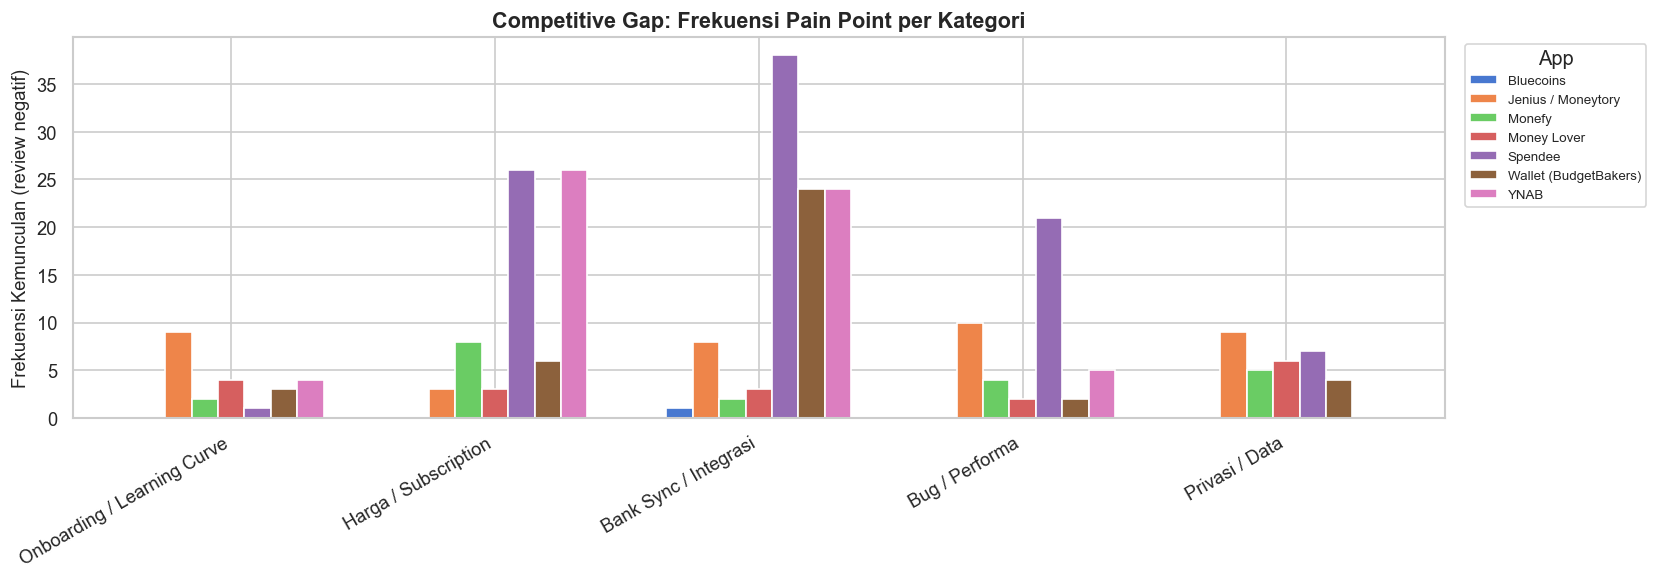

In [15]:
TARGET_KW = {
    'Onboarding / Learning Curve': [
        'complicated', 'confusing', 'hard to use', 'learning curve',
        'tutorial', 'how to', 'ribet', 'susah', 'bingung', 'cara'
    ],
    'Harga / Subscription': [
        'expensive', 'subscription', 'price', 'cost', 'pay', 'free',
        'mahal', 'berbayar', 'gratis', 'bayar'
    ],
    'Bank Sync / Integrasi': [
        'sync', 'bank', 'connect', 'import', 'link',
        'sinkron', 'terhubung', 'integrasi'
    ],
    'Bug / Performa': [
        'crash', 'bug', 'slow', 'freeze', 'error',
        'lambat', 'gangguan', 'gagal'
    ],
    'Privasi / Data': [
        'privacy', 'secure', 'data', 'private',
        'aman', 'keamanan', 'privasi'
    ]
}

neg_reviews = df[df['Rating'] <= 2].copy()

gap_rows = []
for app in sorted(neg_reviews['App_label'].unique()):
    app_texts = neg_reviews[neg_reviews['App_label'] == app]['Review_lower']
    row = {'App': app}
    for category, keywords in TARGET_KW.items():
        count = sum(1 for text in app_texts for kw in keywords if kw in text)
        row[category] = count
    gap_rows.append(row)

gap_df = pd.DataFrame(gap_rows).set_index('App')
print('Pain Point Frequency per App (dari review negatif):')
print(gap_df.to_string())

fig, ax = plt.subplots(figsize=(14, 5))
gap_df.T.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')
ax.set_title('Competitive Gap: Frekuensi Pain Point per Kategori', fontweight='bold')
ax.set_ylabel('Frekuensi Kemunculan (review negatif)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='App', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

---
## 8. Kesimpulan & Rekomendasi VPD

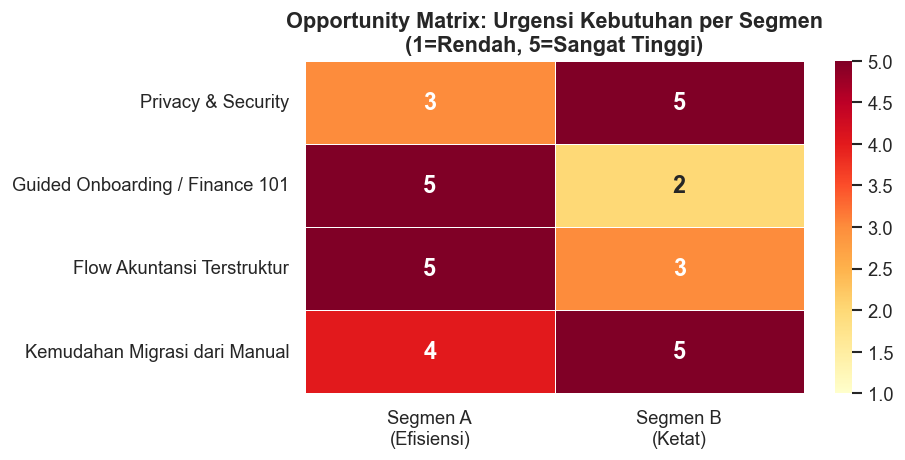

In [16]:
opportunity = pd.DataFrame({
    'Segmen A\n(Efisiensi)': [3, 5, 5, 4],
    'Segmen B\n(Ketat)': [5, 2, 3, 5]
}, index=[
    'Privacy & Security',
    'Guided Onboarding / Finance 101',
    'Flow Akuntansi Terstruktur',
    'Kemudahan Migrasi dari Manual'
])

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(opportunity, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=1, vmax=5,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_title('Opportunity Matrix: Urgensi Kebutuhan per Segmen\n(1=Rendah, 5=Sangat Tinggi)',
             fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

In [17]:
print("""
==========================================================================
  RINGKASAN INSIGHT — SURFING WHALE FINANCE
==========================================================================

SEGMEN A: Si Pencari Efisiensi
  Pain:
    - Tidak ada panduan memahami flow keuangan (Finance 101)
    - Onboarding kompleks, kurva belajar tinggi (dominan di YNAB review negatif)
    - Fitur bank sync sering jadi sumber frustrasi ketika tidak bekerja
  Opportunity:
    - Built-in Finance 101: ajarkan cara berpikir akuntansi SEBELUM input data
    - Template siap pakai (pengeluaran bulanan, kategori standar)
    - Tooltip kontekstual di setiap langkah onboarding
  Evidensi dari data:
    - YNAB: keyword 'complicated', 'how to', 'learn' dominan di review bintang 1-2

SEGMEN B: Si Pengendali Ketat
  Pain:
    - Tidak yakin data aman disimpan di cloud
    - UI terlalu kompleks, tidak perlu fitur canggih
    - Resistensi migrasi dari buku manual / struk fisik
  Opportunity:
    - Privacy-first messaging yang eksplisit (enkripsi, kontrol data)
    - Wizard onboarding 3 langkah yang mirror habit manual (catat > kategorikan > lihat)
    - Mode offline sebagai trust signal utama
  Evidensi dari data:
    - Monefy & Bluecoins: rating tinggi karena simplicity, tapi keluhan di data security

CROSS-MARKET:
  US: sensitif ke harga (subscription) dan reliability bank sync
  ID: sensitif ke bug/reliability dan learning curve bahasa/UI

REKOMENDASI POSITIONING:
  Segmen A: 'Sistem keuangan lengkap untuk yang mau belajar, bukan sekadar catat'
  Segmen B: 'Data kamu, kontrol kamu — sesimpel buku catatan, sepintar spreadsheet'
""")


  RINGKASAN INSIGHT — SURFING WHALE FINANCE

SEGMEN A: Si Pencari Efisiensi
  Pain:
    - Tidak ada panduan memahami flow keuangan (Finance 101)
    - Onboarding kompleks, kurva belajar tinggi (dominan di YNAB review negatif)
    - Fitur bank sync sering jadi sumber frustrasi ketika tidak bekerja
  Opportunity:
    - Built-in Finance 101: ajarkan cara berpikir akuntansi SEBELUM input data
    - Template siap pakai (pengeluaran bulanan, kategori standar)
    - Tooltip kontekstual di setiap langkah onboarding
  Evidensi dari data:
    - YNAB: keyword 'complicated', 'how to', 'learn' dominan di review bintang 1-2

SEGMEN B: Si Pengendali Ketat
  Pain:
    - Tidak yakin data aman disimpan di cloud
    - UI terlalu kompleks, tidak perlu fitur canggih
    - Resistensi migrasi dari buku manual / struk fisik
  Opportunity:
    - Privacy-first messaging yang eksplisit (enkripsi, kontrol data)
    - Wizard onboarding 3 langkah yang mirror habit manual (catat > kategorikan > lihat)
    - Mode of

---
## Appendix: Data Quality Check

In [18]:
print('=== DATA QUALITY ===')
print(f'Total reviews: {len(df)}')
print(f'Missing Rating: {df["Rating"].isna().sum()}')
print(f'Missing Sentiment: {df["Sentiment_Score"].isna().sum()}')
print(f'Empty Review: {(df["Review"] == "").sum()}')
print(f'\nReviews per App:')
print(df.groupby(['Market', 'App_label']).size().to_string())
print(f'\nSentiment Score range: {df["Sentiment_Score"].min():.2f} to {df["Sentiment_Score"].max():.2f}')

=== DATA QUALITY ===
Total reviews: 1050
Missing Rating: 0
Missing Sentiment: 0
Empty Review: 0

Reviews per App:
Market  App_label            
ID      Bluecoins                100
        Jenius / Moneytory       100
        Monefy                   100
        Money Lover              100
        Spendee                  100
        Wallet (BudgetBakers)    100
US      Spendee                  150
        Wallet (BudgetBakers)    150
        YNAB                     150

Sentiment Score range: -0.90 to 0.90
